<a href="https://colab.research.google.com/github/ArijiS06/financial-markets-analysis/blob/main/financial_markets_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Financial Markets Performance & Risk Analysis**

## Apple vs Microsoft vs NVIDIA vs GOOGLE vs S&P 500

This project analyses the historical performance and risk characteristics of Apple, Microsoft, NVIDIA and the S&P 500 between 2020 and 2026.

The analysis uses Python, pandas, yfinance and data visualisation to compare returns, volatility, drawdowns, correlations and risk-adjusted performance.



In [23]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
tickers = ["AAPL", "MSFT", "NVDA", "GOOGL" , "^GSPC"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2026-09-10"
)

prices = data["Close"]

prices.head()

/tmp/ipykernel_2157/3725350247.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,GOOGL,MSFT,NVDA,^GSPC
Date,,,,,
2020-01-02,72.271538,67.788933,151.544296,5.957139,3257.850098
2020-01-03,71.568924,67.434311,149.657288,5.861788,3234.850098
2020-01-06,72.139191,69.231712,150.044113,5.886370,3246.280029
2020-01-07,71.799896,69.097977,148.675995,5.957634,3237.179932
2020-01-08,72.954926,69.589806,151.044189,5.968808,3253.050049


In [25]:
print(prices.shape)
print()
print(prices.isna().sum())

(1680, 5)

Ticker
AAPL     0
GOOGL    0
MSFT     0
NVDA     0
^GSPC    0
dtype: int64


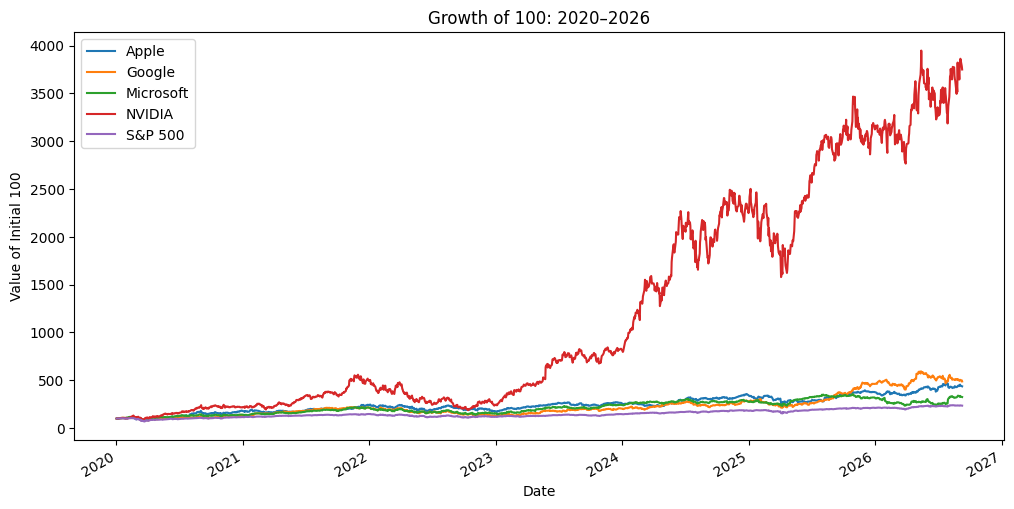

In [26]:
normalized_prices = prices / prices.iloc[0] * 100

normalized_prices = normalized_prices.rename(columns={
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
    "GOOGL": "Google",
    "^GSPC": "S&P 500"
})

normalized_prices.plot(figsize=(12, 6))

plt.title("Growth of 100: 2020–2026")
plt.xlabel("Date")
plt.ylabel("Value of Initial 100")
plt.legend()

plt.show()

In [27]:
daily_returns = prices.pct_change().dropna()

total_returns = (prices.iloc[-1] / prices.iloc[0] - 1) * 100

annual_volatility = (daily_returns.std()* (252 ** 0.5)* 100)

running_peak = prices.cummax()

drawdowns = prices / running_peak - 1

max_drawdowns = drawdowns.min() * 100

start_date = prices.index[0]
end_date = prices.index[-1]

days = (end_date - start_date).days
years = days / 365.25

cagr = ((prices.iloc[-1] / prices.iloc[0]) ** (1 / years) - 1) * 100

risk_free_rate = 0.04

daily_risk_free_rate = ((1 + risk_free_rate) ** (1 / 252)) - 1

excess_returns = daily_returns - daily_risk_free_rate

sharpe_ratio = (excess_returns.mean()/ daily_returns.std()) * (252 ** 0.5)


In [28]:
name_map = {
    "AAPL": "Apple",
    "MSFT": "Microsoft",
    "NVDA": "NVIDIA",
    "GOOGL": "Google",
    "^GSPC": "S&P 500"
}

In [29]:
total_returns = total_returns.rename(index=name_map)
annual_volatility = annual_volatility.rename(index=name_map)
max_drawdowns = max_drawdowns.rename(index=name_map)
cagr = cagr.rename(index=name_map)
sharpe_ratio = sharpe_ratio.rename(index=name_map)

In [30]:
summary = pd.DataFrame({
    "Total Return (%)": total_returns,
    "CAGR (%)": cagr,
    "Annual Volatility (%)": annual_volatility,
    "Maximum Drawdown (%)": max_drawdowns,
    "Sharpe Ratio": sharpe_ratio
})

summary = summary.round(2)

summary

,Total Return (%),CAGR (%),Annual Volatility (%),Maximum Drawdown (%),Sharpe Ratio
Ticker,,,,,
Apple,336.33,24.65,31.35,-33.36,0.74
Google,387.76,26.75,32.50,-44.32,0.77
Microsoft,224.43,19.25,30.42,-37.15,0.60
NVIDIA,3650.46,71.96,51.92,-66.34,1.23
S&P 500,134.40,13.59,20.28,-33.92,0.54


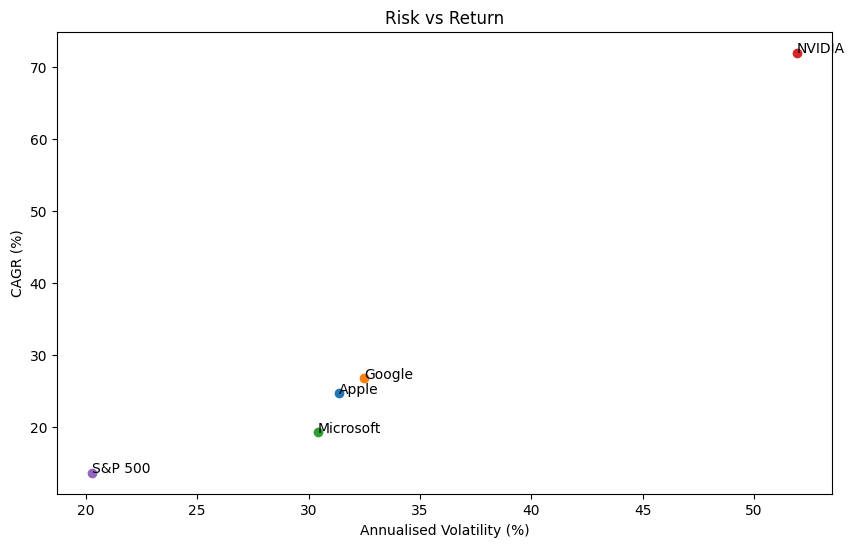

In [31]:
plt.figure(figsize=(10, 6))

for asset in summary.index:

  volatility = summary.loc[asset,"Annual Volatility (%)"]

  growth = summary.loc[asset,"CAGR (%)"]

  plt.scatter(volatility, growth)

  plt.text(volatility,growth,asset)

plt.title("Risk vs Return")
plt.xlabel("Annualised Volatility (%)")
plt.ylabel("CAGR (%)")

plt.show()

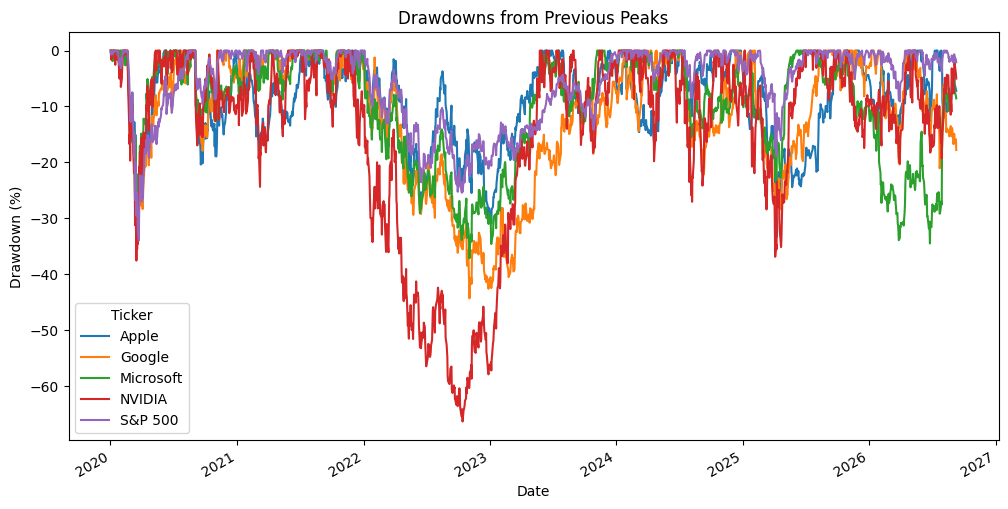

In [32]:
drawdowns_percent = drawdowns * 100

drawdowns_display = drawdowns_percent.rename(columns=name_map)

drawdowns_display.plot(figsize=(12, 6))

plt.title("Drawdowns from Previous Peaks")
plt.xlabel("Date")
plt.ylabel("Drawdown (%)")

plt.show()

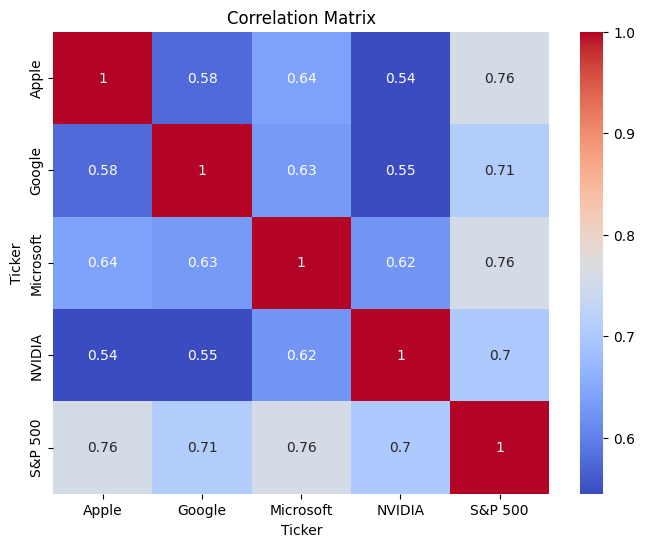

In [33]:
correlation_matrix = daily_returns.corr()

correlation_display = correlation_matrix.rename(
    index=name_map,
    columns=name_map
)

plt.figure(figsize=(8, 6))

sns.heatmap(correlation_display, annot=True, cmap="coolwarm")

plt.title("Correlation Matrix")

plt.show()

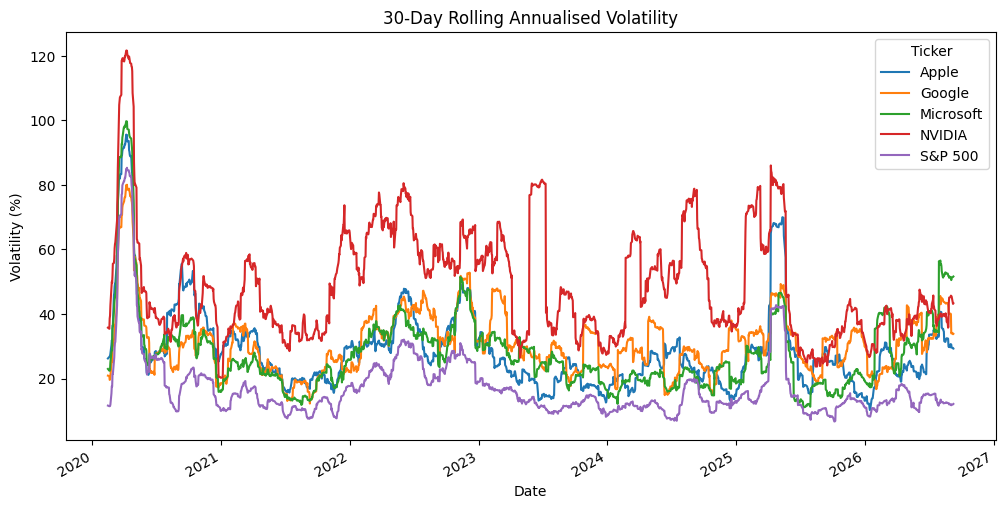

In [34]:
rolling_volatility = (daily_returns.rolling(window=30).std()* (252 ** 0.5)* 100)

rolling_volatility = rolling_volatility.rename(columns=name_map)

rolling_volatility.plot(figsize=(12, 6))

plt.title("30-Day Rolling Annualised Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.show()

In [35]:
print("Key Statistical Findinds")
print("------------------------")

highest_return = summary["Total Return (%)"].idxmax()

print("Highest total return:", highest_return)

highest_cagr = summary["CAGR (%)"].idxmax()

print("Highest CAGR:", highest_cagr)

highest_annual_volatility = summary["Annual Volatility (%)"].idxmax()

print("Highest annual volatility:", highest_annual_volatility)

lowest_annual_volatility = summary["Annual Volatility (%)"].idxmin()

print("Lowest annual volatility:", lowest_annual_volatility)

highest_max_drawdown = summary["Maximum Drawdown (%)"].idxmax()

print("Highest maximum drawdown:", highest_max_drawdown)

worst_max_drawdown = summary["Maximum Drawdown (%)"].idxmin()

print("Worst maximum drawdown:", worst_max_drawdown)

best_sharpe = summary["Sharpe Ratio"].idxmax()

print("Best Sharpe Ratio:", best_sharpe)

Key Statistical Findinds
------------------------
Highest total return: NVIDIA
Highest CAGR: NVIDIA
Highest annual volatility: NVIDIA
Lowest annual volatility: S&P 500
Highest maximum drawdown: Apple
Worst maximum drawdown: NVIDIA
Best Sharpe Ratio: NVIDIA


## Key findings
- NVIDIA generated the strongest overall growth during the analysis period, but this performance was accompanied by substantially higher volatility.

- The S&P 500 showed lower volatility than the individual technology stocks (Apple, Microsoft, NVIDIA and Google) highlighting the potential risk reduction benefits of broader diversification.

- Maximum drawdown analysis showed that strong long-term returns did not prevent the technology stocks from experiencing substantial temporary losses during periods of market stress.

- Apple, Microsoft, NVIDIA and Google exhibited positive return correlations, suggesting that holding several large technology companies alone may provide limited diversification because their returns often moved in the same direction.

- Risk adjusted performance differed from absolute performance, demonstrating that the asset with the highest total return was not necessarily superior across other measures such as volatility, maximum drawdown and the Sharpe ratio.

- Google's inclusion provided an additional comparison within the large cap technology sector, allowing differences in performance, risk and correlation to be assessed across a broader group of major technology companies.

## Limitations
The analysis has several limitations.

First, the results cover the period from 2020 to the latest available market data and may differ significantly when using other time horizons. The selected period also includes several unusual market conditions, meaning the results may not be representative of longer-term historical performance.

Second, the project focuses primarily on historical market price behaviour and does not incorporate company fundamentals, valuation measures, macroeconomic variables or forecasts of future returns.

Third, correlations are estimated using historical returns and can change over time, particularly during periods of market stress. Therefore, past correlations should not be assumed to remain constant in the future.

The Sharpe ratio also uses standard deviation as its measure of risk, meaning positive and negative volatility are treated equally even though investors may be more concerned with downside movements.

Finally, all results are based on historical data. Past performance, risk characteristics and relationships between the assets do not guarantee similar behaviour in the future.

## Conclusion

This analysis demonstrates that investment performance cannot be evaluated using return alone.

The assets differed substantially in growth, volatility, drawdown behaviour and risk adjusted performance. Correlation analysis also showed that assets can share significant common movements, which affects the diversification benefit of combining them.

Rolling analysis further demonstrated that financial risk is not constant over time and can increase sharply during periods of market stress.

Overall, the project highlights the importance of analysing both return and risk when comparing financial assets.